### Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

### Map Locations to Model Labels

In [2]:
# All label names in the public HPA and their corresponding index. 
all_locations = dict({
    "nucleoplasm": 0,
    "nuclear membrane": 1,
    "nucleoli": 2,
    "nucleoli fibrillar center": 3,
    "nuclear speckles": 4,
    "nuclear bodies": 5,
    "endoplasmic reticulum": 6,
    "golgi apparatus": 7,
    "intermediate filaments": 8,
    "actin filaments": 9,
    "focal adhesion sites": 9,
    "microtubules": 10,
    "mitotic spindle": 11,
    "centrosome": 12,
    "centriolar satellite": 12,
    "plasma membrane": 13,
    "cell junctions": 13,
    "mitochondria": 14,
    "aggresome": 15,
    "cytosol": 16,
    "vesicles": 17,
    "peroxisomes": 17,
    "endosomes": 17,
    "lysosomes": 17,
    "lipid droplets": 17,
    "cytoplasmic bodies": 17,
    "no staining": 18
})

### Read Data

In [3]:
df = pd.read_csv('v24_hpa_subcellular_location_expanded.csv')
df = df[['Image', 'Location', 'Verification', 'Gene ID']]
df


,Image,Location,Verification,Gene ID
0,https://images.proteinatlas.org/4109/1832_C1_2...,"['nucleoli fibrillar center (GO:0001650)', 'cy...",approved,ENSG00000000003
1,https://images.proteinatlas.org/4109/1832_C1_4...,"['nucleoli fibrillar center (GO:0001650)', 'cy...",approved,ENSG00000000003
2,https://images.proteinatlas.org/4109/1843_B2_1...,"['nucleoli fibrillar center (GO:0001650)', 'ce...",approved,ENSG00000000003
3,https://images.proteinatlas.org/4109/1843_B2_3...,"['nucleoli fibrillar center (GO:0001650)', 'ce...",approved,ENSG00000000003
4,https://images.proteinatlas.org/4109/23_H11_1_...,['cytosol (GO:0005829)'],approved,ENSG00000000003
...,...,...,...,...
83355,https://images.proteinatlas.org/59543/1282_B2_...,[],approved,ENSG00000291316
83356,https://images.proteinatlas.org/59543/1218_C5_...,['nucleoplasm (GO:0005654)'],approved,ENSG00000291316
83357,https://images.proteinatlas.org/59543/1218_C5_...,['nucleoplasm (GO:0005654)'],approved,ENSG00000291316
83358,https://images.proteinatlas.org/59543/1018_C5_...,[],approved,ENSG00000291316


In [4]:
df['Location'] = df['Location'].apply(lambda x: eval(x))
df['Location'] = df['Location'].apply(lambda x: [" ".join(loc.split()[:-1]) for loc in x])
df['Location'][0]

['nucleoli fibrillar center', 'cytosol']

### Compare and Remove Extra Locations

In [5]:
# Show df locations
hpav24_locations = set()
for loc in df['Location']:
    hpav24_locations.update(loc)
hpav24_locations

{'acrosome',
 'actin filaments',
 'aggresome',
 'annulus',
 'basal body',
 'calyx',
 'cell junctions',
 'centriolar satellite',
 'centrosome',
 'cleavage furrow',
 'connecting piece',
 'cytokinetic bridge',
 'cytoplasmic bodies',
 'cytosol',
 'end piece',
 'endoplasmic reticulum',
 'endosomes',
 'equatorial segment',
 'flagellar centriole',
 'focal adhesion sites',
 'golgi apparatus',
 'intermediate filaments',
 'kinetochore',
 'lipid droplets',
 'lysosomes',
 'microtubule ends',
 'microtubules',
 'mid piece',
 'midbody',
 'midbody ring',
 'mitochondria',
 'mitotic chromosome',
 'mitotic spindle',
 'nuclear bodies',
 'nuclear membrane',
 'nuclear speckles',
 'nucleoli',
 'nucleoli fibrillar center',
 'nucleoli rim',
 'nucleoplasm',
 'perinuclear theca',
 'peroxisomes',
 'plasma membrane',
 'primary cilium',
 'primary cilium tip',
 'primary cilium transition zone',
 'principal piece',
 'rods & rings',
 'vesicles'}

In [6]:
# Check what locations from hpav24_locations are not in all_locations
hpav24_extra_locations = []
for loc in hpav24_locations:
    if loc not in all_locations:
        hpav24_extra_locations.append(loc)
hpav24_extra_locations

['mid piece',
 'rods & rings',
 'basal body',
 'connecting piece',
 'principal piece',
 'acrosome',
 'primary cilium',
 'end piece',
 'midbody',
 'mitotic chromosome',
 'microtubule ends',
 'midbody ring',
 'calyx',
 'cleavage furrow',
 'annulus',
 'kinetochore',
 'equatorial segment',
 'cytokinetic bridge',
 'perinuclear theca',
 'primary cilium tip',
 'primary cilium transition zone',
 'nucleoli rim',
 'flagellar centriole']

In [7]:
# Print percentage of images
print(f"Percentage of images with HPA extra locations: {
    len(df[df['Location'].apply(lambda x: any(loc in x for loc in hpav24_extra_locations))]) / len(df) * 100:.2f
}%")

# Check how many images of hpav24_extra_locations
df[df['Location'].apply(lambda x: any(loc in x for loc in hpav24_extra_locations))]

# Remove those images
df_mapped = df[~df['Location'].apply(lambda x: any(loc in x for loc in hpav24_extra_locations))].copy()

Percentage of images with HPA extra locations: 5.89%


### Map Locations to Model Classification Labels

In [8]:
# Map locations to model classification labels from all_locations
df_mapped['Location'] = df_mapped['Location'].apply(lambda x: set(all_locations[loc] for loc in x if loc in all_locations))
# Where is empty, put 18
df_mapped['Location'] = df_mapped['Location'].apply(lambda x: x if x else {18})

df_mapped['Location']

0            {16, 3}
1            {16, 3}
2        {16, 3, 13}
3        {16, 3, 13}
4               {16}
            ...     
83355           {18}
83356            {0}
83357            {0}
83358           {18}
83359           {18}
Name: Location, Length: 78453, dtype: object

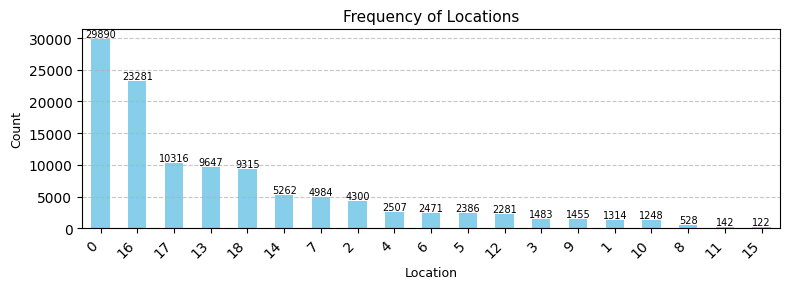

In [9]:
# Prepare the data
location_counts = df_mapped['Location'].explode().value_counts()

# Create the plot
plt.figure(figsize=(8, 3))  # Width x Height in inches
location_counts.plot(kind='bar', color='skyblue')

# Add labels and title
# Add values on top of bars (sorted by bar height)
for i, v in enumerate(location_counts):
    plt.text(i, v, v, ha='center', va='bottom', fontsize=7)

plt.title('Frequency of Locations', fontsize=11)
plt.xlabel('Location', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid for visual clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

In [10]:
df_train_kaggle = pd.read_csv('../hpa-datasets/train_kaggle_2021/train.csv')
# Split | into separate labels
df_train_kaggle['Label'] = df_train_kaggle['Label'].str.split('|')
df_train_kaggle

,ID,Label
0,5c27f04c-bb99-11e8-b2b9-ac1f6b6435d0,"[8, 5, 0]"
1,5fb643ee-bb99-11e8-b2b9-ac1f6b6435d0,"[14, 0]"
2,60b57878-bb99-11e8-b2b9-ac1f6b6435d0,"[6, 1]"
3,5c1a898e-bb99-11e8-b2b9-ac1f6b6435d0,"[16, 10]"
4,5b931256-bb99-11e8-b2b9-ac1f6b6435d0,"[14, 0]"
...,...,...
21801,dd0989c4-bbca-11e8-b2bc-ac1f6b6435d0,[14]
21802,dd1f7fb8-bbca-11e8-b2bc-ac1f6b6435d0,"[3, 0]"
21803,dd5cb36a-bbca-11e8-b2bc-ac1f6b6435d0,"[14, 0]"
21804,df573730-bbca-11e8-b2bc-ac1f6b6435d0,[14]


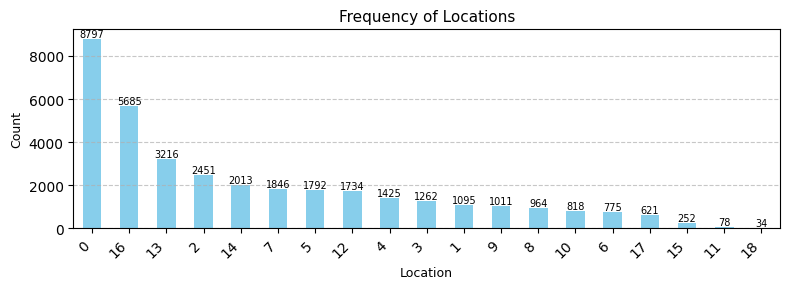

In [11]:
# Plot how many labels of each class
# Prepare the data
location_counts = df_train_kaggle['Label'].explode().value_counts()

# Create the plot
plt.figure(figsize=(8, 3))  # Width x Height in inches
location_counts.plot(kind='bar', color='skyblue')

# Add labels and title
# Add values on top of bars (sorted by bar height)
for i, v in enumerate(location_counts):
    plt.text(i, v, v, ha='center', va='bottom', fontsize=7)

plt.title('Frequency of Locations', fontsize=11)
plt.xlabel('Location', fontsize=9)
plt.ylabel('Count', fontsize=9)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add grid for visual clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

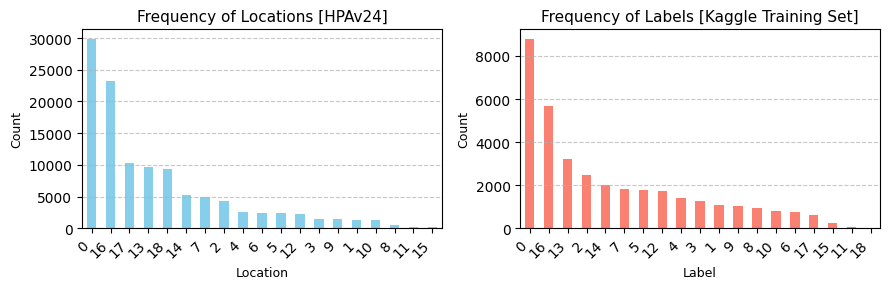

In [12]:
# Put the two plot that I made together
plt.figure(figsize=(9, 3))

# Plot for Location
plt.subplot(1, 2, 1)
location_counts = df_mapped['Location'].explode().value_counts()
location_counts.plot(kind='bar', color='skyblue')
plt.title('Frequency of Locations [HPAv24]', fontsize=11)
plt.xlabel('Location', fontsize=9)
plt.ylabel('Count', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot for Label
plt.subplot(1, 2, 2)
label_counts = df_train_kaggle['Label'].explode().value_counts()
label_counts.plot(kind='bar', color='salmon')
plt.title('Frequency of Labels [Kaggle Training Set]', fontsize=11)
plt.xlabel('Label', fontsize=9)
plt.ylabel('Count', fontsize=9)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [18]:
# Create new column with image name only
df_mapped['Image ID'] = df_mapped['Image'].apply(lambda x: (x.split('/')[-1]).split('_blue')[0])
df_mapped

,Image,Location,Verification,Gene ID,Image ID
0,https://images.proteinatlas.org/4109/1832_C1_2...,"{16, 3}",approved,ENSG00000000003,1832_C1_2
1,https://images.proteinatlas.org/4109/1832_C1_4...,"{16, 3}",approved,ENSG00000000003,1832_C1_4
2,https://images.proteinatlas.org/4109/1843_B2_1...,"{16, 3, 13}",approved,ENSG00000000003,1843_B2_17_cr5af971a263864
3,https://images.proteinatlas.org/4109/1843_B2_3...,"{16, 3, 13}",approved,ENSG00000000003,1843_B2_30_cr5af971a2648d6
4,https://images.proteinatlas.org/4109/23_H11_1_...,{16},approved,ENSG00000000003,23_H11_1
...,...,...,...,...,...
83355,https://images.proteinatlas.org/59543/1282_B2_...,{18},approved,ENSG00000291316,1282_B2_4
83356,https://images.proteinatlas.org/59543/1218_C5_...,{0},approved,ENSG00000291316,1218_C5_1
83357,https://images.proteinatlas.org/59543/1218_C5_...,{0},approved,ENSG00000291316,1218_C5_3
83358,https://images.proteinatlas.org/59543/1018_C5_...,{18},approved,ENSG00000291316,1018_C5_1


In [ ]:
# Create column called in_train_set
# This column should be 1 if the image is already at df_train_kaggle
df_mapped['in_train_set'] = df_mapped['Image ID'].isin(df_train_kaggle['ID']).astype(int)
df_mapped[df_mapped['in_train_set']==1]


In [32]:
# classes names: all except 0 and 16
CLASSES_TO_DOWNLOAD_IMAGES = [cls for cls in set(all_locations.values()) if cls not in [0, 16]]
CLASSES_TO_DOWNLOAD_IMAGES

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18]

In [35]:
# If any location is in CLASSES_TO_DOWNLOAD_IMAGES, keep it
df_mapped['to_download'] = df_mapped['Location'].apply(lambda x: any(loc in x for loc in CLASSES_TO_DOWNLOAD_IMAGES)).astype(int)

In [36]:
sum(df_mapped['to_download']==1)

52791